# Análisis de resultados — Oscilador Armónico Cuántico (QHO)

Este notebook analiza los resultados del estudio de sensibilidad sobre la PINN
aplicada al oscilador armónico cuántico. Se estudian los siguientes ejes:

1. **Puntos de colocación**: 50, 100, 250, 500 (base), 1000
2. **Sampler**: LHS (base) vs. grid
3. **Optimizador**: Adam (base) vs. Adam+L-BFGS
4. **Arquitectura**: [32,32,32] (base) vs. [64,64,64]
5. **Pesos dinámicos**: desactivados (base) vs. activados
6. **Learning rate**: 0.001 (base) vs. 0.01
7. **Puntos de entrenamiento**: 3, 5, 10, 15 (base), 30
8. **Región de entrenamiento**: 50% (base) vs. 30%
9. **Cruce puntos × región**: combinaciones con región 30%
10. **Estado cuántico**: n = 0, 1 (base), 2, 3
11. **Sin datos supervisados**: solo física (use_data = False)
12. **Ortogonalidad**: desactivada (base) vs. activada

Cada configuración se ejecuta con 10 seeds distintas.
La referencia numérica es FDM (Diferencias Finitas).
La PINN aprende el autovalor $\varepsilon$ como parámetro adicional,
lo que permite comparar su precisión frente al valor exacto y al FDM.

In [14]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch

mpl.rcParams.update({
    "font.family":         "serif",
    "font.size":           12,
    "axes.linewidth":      1.2,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi":          150,
})

RESULTS_DIR = Path("results")
FIGS_DIR    = Path("figures_analysis_qho")
FIGS_DIR.mkdir(exist_ok=True)

C_PINN = "#1f4e96"
C_NN   = "#e07b39"
C_FDM  = "#888888"

In [15]:
import pandas as pd
import json

records_qho = []

for fpath in sorted(RESULTS_DIR.glob("qho/**/*.json")):
    with open(fpath) as f:
        d = json.load(f)

    cfg = d["config"]
    res = d["resultados_finales"]

    records_qho.append({
        # ── Ruta del archivo (¡CLAVE PARA PODER BORRARLOS LUEGO!) ──
        "filename":            str(fpath), 
        
        # ── Configuración ──────────────────────────────────────────
        "seed":                cfg["seed"],
        "estado_n":            cfg["estado_n"],
        "epochs":              cfg["epochs"],
        "lr":                  cfg["lr"],
        "num_domain_points":   cfg["num_domain_points"],
        "num_train_points":    cfg["num_train_points"],
        "train_region":        cfg["train_region"],
        "sampler":             cfg["sampler"],
        "use_dynamic_weights": cfg["use_dynamic_weights"],
        "use_orthogonality":   cfg["use_orthogonality"],
        "optimizer":           cfg["optimizer"],
        "hidden_layers":       str(cfg["hidden_layers"]),
        "use_data":            cfg["use_data"],
        # ── Resultados PINN ────────────────────────────────────────
        "error_l2_pinn":       res["pinn"]["error_L2"],
        "time_pinn":           res["pinn"]["time_s"],
        "epsilon_exacto":      res["pinn"]["epsilon_exacto"],
        "epsilon_learned":     res["pinn"]["epsilon_learned"],
        # ── Resultados NN pura ─────────────────────────────────────
        "error_l2_nn":         res["nn"]["error_L2"],
        "time_nn":             res["nn"]["time_s"],
        # ── Resultados FDM ─────────────────────────────────────────
        "error_l2_fdm":        res["fdm"]["error_L2"],
        "time_fdm":            res["fdm"]["time_s"],
        "epsilon_fdm":         res["fdm"]["epsilon_fdm"],
    })

df_qho = pd.DataFrame(records_qho)
print(f"Total experimentos cargados: {len(df_qho)}")
print(f"Estados cuánticos presentes: {sorted(df_qho['estado_n'].unique())}")
df_qho.head()

Total experimentos cargados: 250
Estados cuánticos presentes: [0, 1, 2, 3]


,filename,seed,estado_n,epochs,lr,num_domain_points,num_train_points,train_region,sampler,use_dynamic_weights,...,use_data,error_l2_pinn,time_pinn,epsilon_exacto,epsilon_learned,error_l2_nn,time_nn,error_l2_fdm,time_fdm,epsilon_fdm
0,results\qho\estado_0\exp_lhs_20260502_161932.json,42,0,10000,0.001,500,15,0.5,lhs,False,...,True,0.039102,34.322775,0.5,0.497484,1.488188,7.742357,0.000018,0.220011,0.499987
1,results\qho\estado_0\exp_lhs_20260502_162014.json,123,0,10000,0.001,500,15,0.5,lhs,False,...,True,0.001369,33.969357,0.5,0.500047,1.049788,7.717208,0.000018,0.222455,0.499987
2,results\qho\estado_0\exp_lhs_20260502_162056.json,7,0,10000,0.001,500,15,0.5,lhs,False,...,True,0.002360,33.742684,0.5,0.499963,1.120539,7.712526,0.000018,0.213007,0.499987
3,results\qho\estado_0\exp_lhs_20260502_162137.json,99,0,10000,0.001,500,15,0.5,lhs,False,...,True,0.010950,33.632369,0.5,0.500553,1.295871,7.731503,0.000018,0.215005,0.499987
4,results\qho\estado_0\exp_lhs_20260502_162219.json,2024,0,10000,0.001,500,15,0.5,lhs,False,...,True,0.003406,33.526065,0.5,0.499918,1.412658,7.731004,0.000018,0.218993,0.499987


In [16]:
BASE_QHO = {
    "estado_n":            1,
    "num_domain_points":   500,
    "num_train_points":    15,
    "train_region":        0.5,
    "sampler":             "lhs",
    "use_dynamic_weights": False,
    "use_orthogonality":   False,
    "optimizer":           "adam",
    "hidden_layers":       "[32, 32, 32]",
    "lr":                  0.001,
    "use_data":            True,
}

def is_base_qho(row):
    return all(row[k] == v for k, v in BASE_QHO.items())

df_qho["is_base"] = df_qho.apply(is_base_qho, axis=1)
df_base_qho = df_qho[df_qho["is_base"]]

print(f"Experimentos BASE: {len(df_base_qho)} (esperados: 10)")
print(f"\nError L2 PINN — media: {df_base_qho['error_l2_pinn'].mean():.4e} "
      f"± {df_base_qho['error_l2_pinn'].std():.4e}")
print(f"Error L2 NN   — media: {df_base_qho['error_l2_nn'].mean():.4e} "
      f"± {df_base_qho['error_l2_nn'].std():.4e}")
print(f"Error L2 FDM  — media: {df_base_qho['error_l2_fdm'].mean():.4e} "
      f"± {df_base_qho['error_l2_fdm'].std():.4e}")
print(f"\nAutovalor exacto (n=1):  {df_base_qho['epsilon_exacto'].iloc[0]:.6f}")
print(f"Autovalor PINN  — media: {df_base_qho['epsilon_learned'].mean():.6f} "
      f"± {df_base_qho['epsilon_learned'].std():.6f}")
print(f"Autovalor FDM   — media: {df_base_qho['epsilon_fdm'].mean():.6f} "
      f"± {df_base_qho['epsilon_fdm'].std():.6f}")
print(f"\nTiempo PINN — media: {df_base_qho['time_pinn'].mean():.2f}s "
      f"± {df_base_qho['time_pinn'].std():.2f}s")
print(f"Tiempo NN   — media: {df_base_qho['time_nn'].mean():.2f}s "
      f"± {df_base_qho['time_nn'].std():.2f}s")
print(f"Tiempo FDM  — media: {df_base_qho['time_fdm'].mean():.4f}s")

Experimentos BASE: 10 (esperados: 10)

Error L2 PINN — media: 4.4666e-02 ± 1.7125e-02
Error L2 NN   — media: 8.5690e-01 ± 3.1647e-01
Error L2 FDM  — media: 5.2400e-05 ± 0.0000e+00

Autovalor exacto (n=1):  1.500000
Autovalor PINN  — media: 1.500060 ± 0.000620
Autovalor FDM   — media: 1.499937 ± 0.000000

Tiempo PINN — media: 34.10s ± 1.12s
Tiempo NN   — media: 7.79s ± 0.09s
Tiempo FDM  — media: 0.2194s


## Eje 1 — Puntos de colocación

Se varía el número de puntos de colocación entre 50 y 1000, manteniendo el resto
de hiperparámetros en su configuración BASE. La NN pura no depende de este
parámetro y se representa como referencia horizontal.

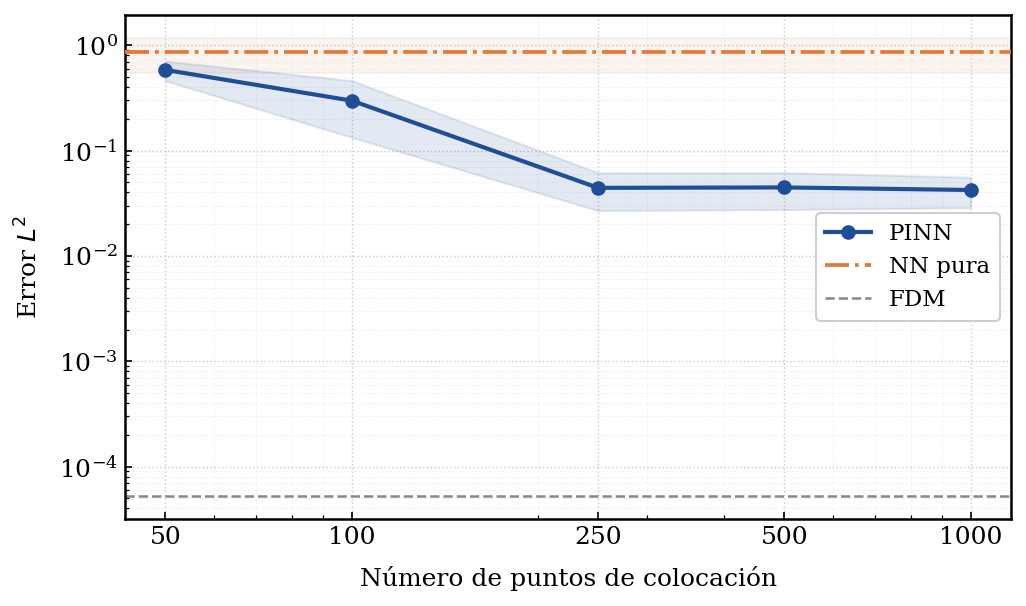

NN pura: 8.5690e-01 ± 3.1647e-01
FDM:     5.2400e-05

PINN por puntos de colocación:
num_domain_points error_l2_pinn          error_l2_nn         
                           mean      std        mean      std
               50      0.582919 0.122877    0.850938 0.300883
              100      0.297772 0.164406    0.856898 0.316473
              250      0.044268 0.017357    0.856898 0.316473
              500      0.044666 0.017125    0.856898 0.316473
             1000      0.042239 0.013614    0.856898 0.316473


In [17]:
configs_eje1 = [50, 100, 250, 500, 1000]

mask_eje1_qho = (
    df_qho["num_domain_points"].isin(configs_eje1) &
    (df_qho["estado_n"]           == BASE_QHO["estado_n"]) &
    (df_qho["num_train_points"]   == BASE_QHO["num_train_points"]) &
    (df_qho["train_region"]       == BASE_QHO["train_region"]) &
    (df_qho["sampler"]            == BASE_QHO["sampler"]) &
    (df_qho["use_dynamic_weights"]== BASE_QHO["use_dynamic_weights"]) &
    (df_qho["use_orthogonality"]  == BASE_QHO["use_orthogonality"]) &
    (df_qho["optimizer"]          == BASE_QHO["optimizer"]) &
    (df_qho["hidden_layers"]      == BASE_QHO["hidden_layers"]) &
    (df_qho["lr"]                 == BASE_QHO["lr"]) &
    (df_qho["use_data"]           == BASE_QHO["use_data"])
)

df_eje1_qho = df_qho[mask_eje1_qho].groupby("num_domain_points")[
    ["error_l2_pinn", "error_l2_nn"]
].agg(["mean", "std"]).reset_index()

x    = df_eje1_qho["num_domain_points"].values
y_p  = df_eje1_qho["error_l2_pinn"]["mean"].values
s_p  = df_eje1_qho["error_l2_pinn"]["std"].values
y_nn = df_base_qho["error_l2_nn"].mean()
s_nn = df_base_qho["error_l2_nn"].std()
y_fdm = df_base_qho["error_l2_fdm"].mean()

fig, ax = plt.subplots(figsize=(7, 4.2))

ax.plot(x, y_p, "o-", color=C_PINN, linewidth=2, markersize=6,
        zorder=3, label="PINN")
ax.fill_between(x, y_p - s_p, y_p + s_p,
                color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(y_nn, color=C_NN, linewidth=1.8, linestyle="-.",
           zorder=3, label="NN pura")
ax.axhspan(y_nn - s_nn, y_nn + s_nn,
           color=C_NN, alpha=0.08, zorder=1)
ax.axhline(y_fdm, color=C_FDM, linewidth=1.2, linestyle="--",
           zorder=2, label="FDM")

ax.set_xlabel("Número de puntos de colocación", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(configs_eje1)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje1_colocation_points.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"NN pura: {y_nn:.4e} ± {s_nn:.4e}")
print(f"FDM:     {y_fdm:.4e}")
print("\nPINN por puntos de colocación:")
print(df_eje1_qho.to_string(index=False))

## Eje 2 — Sampler

Se compara el muestreo Latin Hypercube (LHS) frente a malla uniforme (grid)
para los puntos de colocación. El sampler no afecta a la NN pura, por lo que
se representa como referencia horizontal.

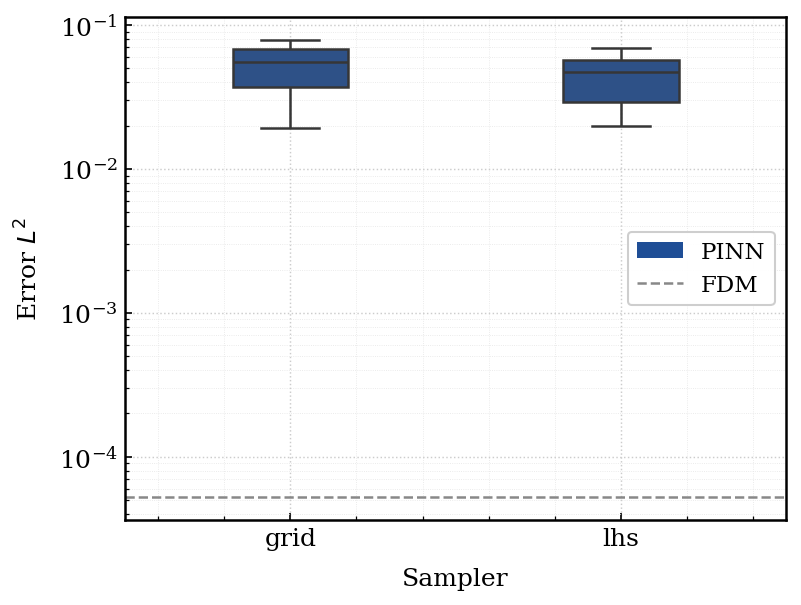

grid: PINN=5.2156e-02 ± 2.1805e-02
lhs: PINN=4.4666e-02 ± 1.7125e-02
NN pura: 8.5690e-01 ± 3.1647e-01
FDM:     5.2400e-05


In [18]:
mask_eje2_qho = (
    df_qho["sampler"].isin(["lhs", "grid"]) &
    (df_qho["estado_n"]           == BASE_QHO["estado_n"]) &
    (df_qho["num_domain_points"]  == BASE_QHO["num_domain_points"]) &
    (df_qho["num_train_points"]   == BASE_QHO["num_train_points"]) &
    (df_qho["train_region"]       == BASE_QHO["train_region"]) &
    (df_qho["use_dynamic_weights"]== BASE_QHO["use_dynamic_weights"]) &
    (df_qho["use_orthogonality"]  == BASE_QHO["use_orthogonality"]) &
    (df_qho["optimizer"]          == BASE_QHO["optimizer"]) &
    (df_qho["hidden_layers"]      == BASE_QHO["hidden_layers"]) &
    (df_qho["lr"]                 == BASE_QHO["lr"]) &
    (df_qho["use_data"]           == BASE_QHO["use_data"])
)

df_eje2_qho = df_qho[mask_eje2_qho][["sampler", "error_l2_pinn"]].copy()

fig, ax = plt.subplots(figsize=(5.5, 4.2))

sns.boxplot(
    data=df_eje2_qho, x="sampler", y="error_l2_pinn",
    color=C_PINN, width=0.35, linewidth=1.2,
    showfliers=False, ax=ax
)

ax.axhline(df_base_qho["error_l2_fdm"].mean(), color=C_FDM, linewidth=1.2,
           linestyle="--", zorder=2, label="FDM")

handles, labels = ax.get_legend_handles_labels()
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=11)

ax.set_xlabel("Sampler", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje2_sampler.png", dpi=300, bbox_inches="tight")
plt.show()

for sampler, grp in df_qho[mask_eje2_qho].groupby("sampler"):
    print(f"{sampler}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e}")
print(f"NN pura: {df_base_qho['error_l2_nn'].mean():.4e} ± {df_base_qho['error_l2_nn'].std():.4e}")
print(f"FDM:     {df_base_qho['error_l2_fdm'].mean():.4e}")

## Eje 3 — Optimizador

Se compara Adam puro frente a la estrategia Adam+L-BFGS. El optimizador afecta
tanto a la PINN como a la NN, por lo que se incluyen ambas en la comparación.

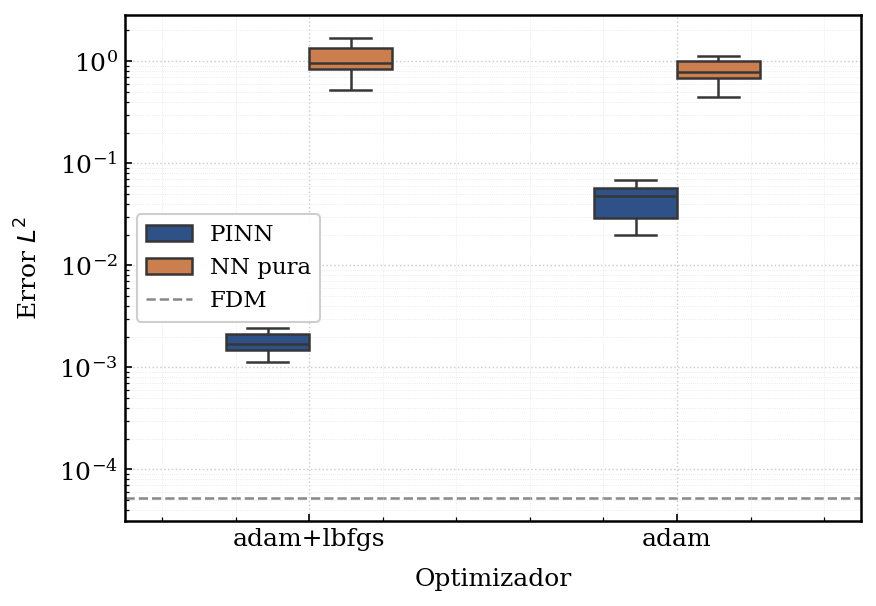

adam: PINN=4.4666e-02 ± 1.7125e-02 | NN=8.5690e-01 ± 3.1647e-01
adam+lbfgs: PINN=1.7897e-03 ± 4.5678e-04 | NN=1.0481e+00 ± 3.6159e-01
FDM: 5.2400e-05


In [19]:
mask_eje3_qho = (
    df_qho["optimizer"].isin(["adam", "adam+lbfgs"]) &
    (df_qho["estado_n"]           == BASE_QHO["estado_n"]) &
    (df_qho["num_domain_points"]  == BASE_QHO["num_domain_points"]) &
    (df_qho["num_train_points"]   == BASE_QHO["num_train_points"]) &
    (df_qho["train_region"]       == BASE_QHO["train_region"]) &
    (df_qho["sampler"]            == BASE_QHO["sampler"]) &
    (df_qho["use_dynamic_weights"]== BASE_QHO["use_dynamic_weights"]) &
    (df_qho["use_orthogonality"]  == BASE_QHO["use_orthogonality"]) &
    (df_qho["hidden_layers"]      == BASE_QHO["hidden_layers"]) &
    (df_qho["lr"]                 == BASE_QHO["lr"]) &
    (df_qho["use_data"]           == BASE_QHO["use_data"])
)

df_eje3_qho_long = df_qho[mask_eje3_qho].melt(
    id_vars=["optimizer"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, ax = plt.subplots(figsize=(6, 4.2))

sns.boxplot(
    data=df_eje3_qho_long, x="optimizer", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(
    df_base_qho["error_l2_fdm"].mean(),
    color=C_FDM, linewidth=1.2, linestyle="--", zorder=0, label="FDM"
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=11, title=None)

ax.set_xlabel("Optimizador", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje3_optimizer.png", dpi=300, bbox_inches="tight")
plt.show()

for opt, grp in df_qho[mask_eje3_qho].groupby("optimizer"):
    print(f"{opt}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print(f"FDM: {df_base_qho['error_l2_fdm'].mean():.4e}")

## Eje 4 — Arquitectura

Se compara la arquitectura base [32, 32, 32] frente a [64, 64, 64]. Al doblar
la capacidad de la red, tanto la PINN como la NN disponen de más parámetros,
por lo que se incluyen ambas en la comparación.

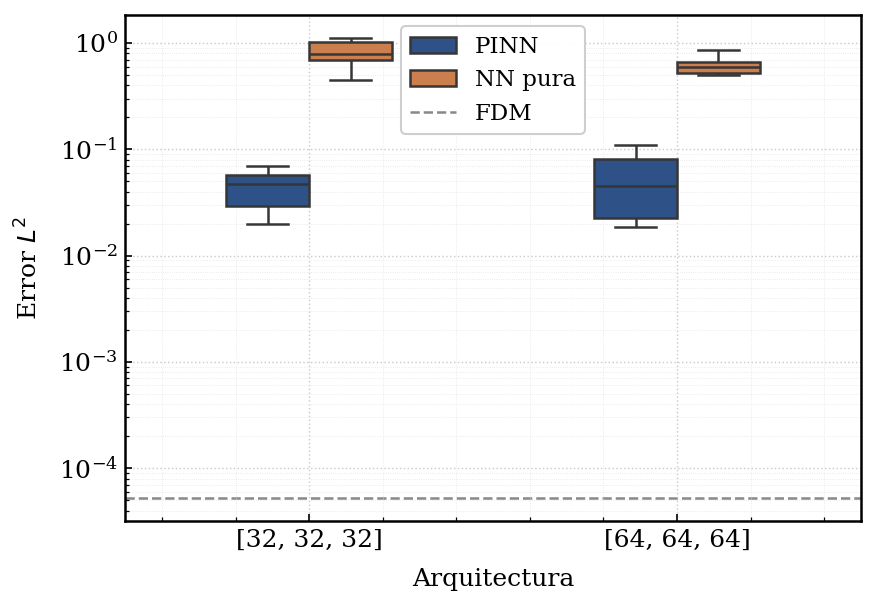

[32, 32, 32]: PINN=4.4666e-02 ± 1.7125e-02 | NN=8.5690e-01 ± 3.1647e-01
[64, 64, 64]: PINN=5.3594e-02 ± 3.4452e-02 | NN=6.1642e-01 ± 1.1826e-01
FDM: 5.2400e-05


In [20]:
mask_eje4_qho = (
    df_qho["hidden_layers"].isin(["[32, 32, 32]", "[64, 64, 64]"]) &
    (df_qho["estado_n"]           == BASE_QHO["estado_n"]) &
    (df_qho["num_domain_points"]  == BASE_QHO["num_domain_points"]) &
    (df_qho["num_train_points"]   == BASE_QHO["num_train_points"]) &
    (df_qho["train_region"]       == BASE_QHO["train_region"]) &
    (df_qho["sampler"]            == BASE_QHO["sampler"]) &
    (df_qho["use_dynamic_weights"]== BASE_QHO["use_dynamic_weights"]) &
    (df_qho["use_orthogonality"]  == BASE_QHO["use_orthogonality"]) &
    (df_qho["optimizer"]          == BASE_QHO["optimizer"]) &
    (df_qho["lr"]                 == BASE_QHO["lr"]) &
    (df_qho["use_data"]           == BASE_QHO["use_data"])
)

df_eje4_qho_long = df_qho[mask_eje4_qho].melt(
    id_vars=["hidden_layers"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, ax = plt.subplots(figsize=(6, 4.2))

sns.boxplot(
    data=df_eje4_qho_long, x="hidden_layers", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(
    df_base_qho["error_l2_fdm"].mean(),
    color=C_FDM, linewidth=1.2, linestyle="--", zorder=0, label="FDM"
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=11, title=None)

ax.set_xlabel("Arquitectura", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje4_architecture.png", dpi=300, bbox_inches="tight")
plt.show()

for arch, grp in df_qho[mask_eje4_qho].groupby("hidden_layers"):
    print(f"{arch}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print(f"FDM: {df_base_qho['error_l2_fdm'].mean():.4e}")

## Eje 5 — Pesos dinámicos

Se compara el entrenamiento con pesos fijos frente a pesos dinámicos adaptativos.
Los pesos dinámicos solo afectan a la PINN; la NN pura es insensible a este
parámetro y se omite de la visualización.

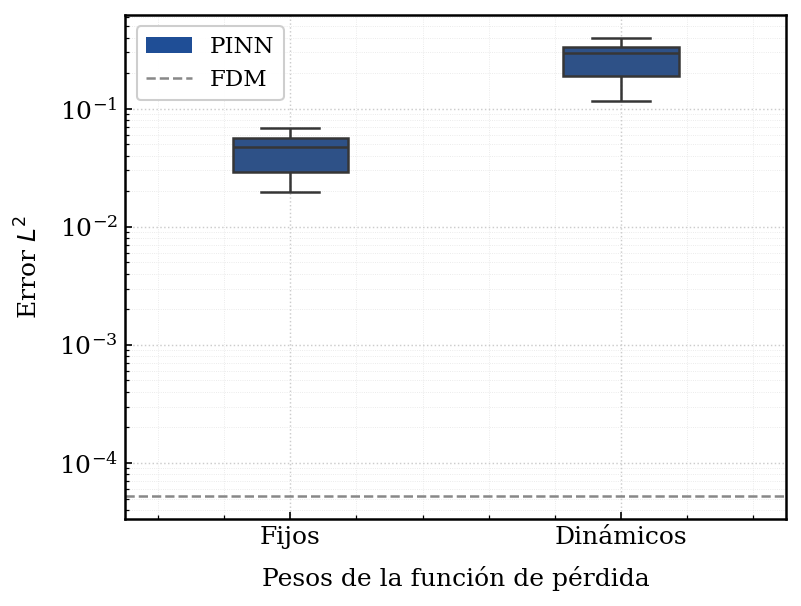

Fijos: PINN=4.4666e-02 ± 1.7125e-02
Dinámicos: PINN=2.6414e-01 ± 9.8612e-02
NN pura: 8.5690e-01 ± 3.1647e-01
FDM:     5.2400e-05


In [21]:
mask_eje5_qho = (
    (df_qho["estado_n"]           == BASE_QHO["estado_n"]) &
    (df_qho["num_domain_points"]  == BASE_QHO["num_domain_points"]) &
    (df_qho["num_train_points"]   == BASE_QHO["num_train_points"]) &
    (df_qho["train_region"]       == BASE_QHO["train_region"]) &
    (df_qho["sampler"]            == BASE_QHO["sampler"]) &
    (df_qho["use_orthogonality"]  == BASE_QHO["use_orthogonality"]) &
    (df_qho["optimizer"]          == BASE_QHO["optimizer"]) &
    (df_qho["hidden_layers"]      == BASE_QHO["hidden_layers"]) &
    (df_qho["lr"]                 == BASE_QHO["lr"]) &
    (df_qho["use_data"]           == BASE_QHO["use_data"])
)

df_eje5_qho = df_qho[mask_eje5_qho].copy()
df_eje5_qho["use_dynamic_weights"] = df_eje5_qho["use_dynamic_weights"].astype(str).map(
    {"False": "Fijos", "True": "Dinámicos"}
)

fig, ax = plt.subplots(figsize=(5.5, 4.2))

sns.boxplot(
    data=df_eje5_qho, x="use_dynamic_weights", y="error_l2_pinn",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    width=0.35, linewidth=1.2, showfliers=False, ax=ax
)

ax.axhline(
    df_base_qho["error_l2_fdm"].mean(),
    color=C_FDM, linewidth=1.2, linestyle="--", zorder=2, label="FDM"
)

handles, labels = ax.get_legend_handles_labels()
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=11)

ax.set_xlabel("Pesos de la función de pérdida", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje5_dynamic_weights.png", dpi=300, bbox_inches="tight")
plt.show()

for dw, grp in df_qho[mask_eje5_qho].groupby("use_dynamic_weights"):
    label = "Dinámicos" if dw else "Fijos"
    print(f"{label}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e}")
print(f"NN pura: {df_base_qho['error_l2_nn'].mean():.4e} ± {df_base_qho['error_l2_nn'].std():.4e}")
print(f"FDM:     {df_base_qho['error_l2_fdm'].mean():.4e}")

## Eje 6 — Learning rate

Se comparan dos tasas de aprendizaje: 0.001 (BASE) y 0.01. El learning rate
afecta tanto a la PINN como a la NN, por lo que se incluyen ambas.

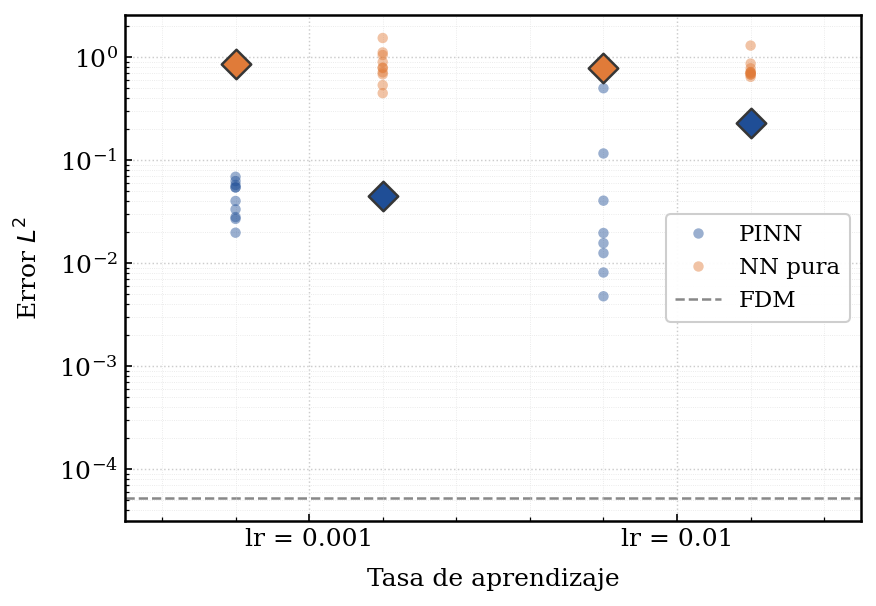

lr=0.001: PINN=4.4666e-02 ± 1.7125e-02 | NN=8.5690e-01 ± 3.1647e-01
lr=0.01: PINN=2.3056e-01 ± 3.3261e-01 | NN=7.7923e-01 ± 1.9322e-01
FDM: 5.2400e-05


In [22]:
mask_eje6_qho = (
    df_qho["lr"].isin([0.001, 0.01]) &
    (df_qho["estado_n"]           == BASE_QHO["estado_n"]) &
    (df_qho["num_domain_points"]  == BASE_QHO["num_domain_points"]) &
    (df_qho["num_train_points"]   == BASE_QHO["num_train_points"]) &
    (df_qho["train_region"]       == BASE_QHO["train_region"]) &
    (df_qho["sampler"]            == BASE_QHO["sampler"]) &
    (df_qho["use_dynamic_weights"]== BASE_QHO["use_dynamic_weights"]) &
    (df_qho["use_orthogonality"]  == BASE_QHO["use_orthogonality"]) &
    (df_qho["optimizer"]          == BASE_QHO["optimizer"]) &
    (df_qho["hidden_layers"]      == BASE_QHO["hidden_layers"]) &
    (df_qho["use_data"]           == BASE_QHO["use_data"])
)

df_eje6_qho = df_qho[mask_eje6_qho].copy()
df_eje6_qho["lr"] = df_eje6_qho["lr"].astype(str)

df_eje6_qho_long = df_eje6_qho.melt(
    id_vars=["lr"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

df_eje6_qho_long["lr_label"] = df_eje6_qho_long["lr"].map(
    {"0.001": "lr = 0.001", "0.01": "lr = 0.01"}
)

fig, ax = plt.subplots(figsize=(6, 4.2))

sns.stripplot(
    data=df_eje6_qho_long, x="lr_label", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    order=["lr = 0.001", "lr = 0.01"],
    dodge=True, size=5, alpha=0.45, jitter=False, ax=ax
)
means_eje6 = df_eje6_qho_long.groupby(["lr_label", "modelo"])["error_l2"].mean().reset_index()
sns.stripplot(
    data=means_eje6, x="lr_label", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    order=["lr = 0.001", "lr = 0.01"],
    dodge=True, size=10, marker="D", jitter=False,
    linewidth=1.2, ax=ax, legend=False
)
ax.axhline(
    df_base_qho["error_l2_fdm"].mean(),
    color=C_FDM, linewidth=1.2, linestyle="--", zorder=0, label="FDM"
)

handles, labels = ax.get_legend_handles_labels()
seen = set(); h, l = [], []
for handle, label in zip(handles, labels):
    if label not in seen:
        seen.add(label); h.append(handle); l.append(label)
ax.legend(h, l, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=11, title=None)

ax.set_xlabel("Tasa de aprendizaje", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje6_lr.png", dpi=300, bbox_inches="tight")
plt.show()

for lr_val, grp in df_qho[mask_eje6_qho].groupby("lr"):
    print(f"lr={lr_val}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print(f"FDM: {df_base_qho['error_l2_fdm'].mean():.4e}")

## Ejes 7 y 9 — Puntos de entrenamiento × región

Se estudia el efecto del número de puntos de entrenamiento supervisado (3, 5, 10,
15, 30) para dos regiones distintas: 50% (BASE) y 30% del dominio. Ambos métodos
se benefician de más datos, por lo que se incluyen PINN y NN en ambos paneles.

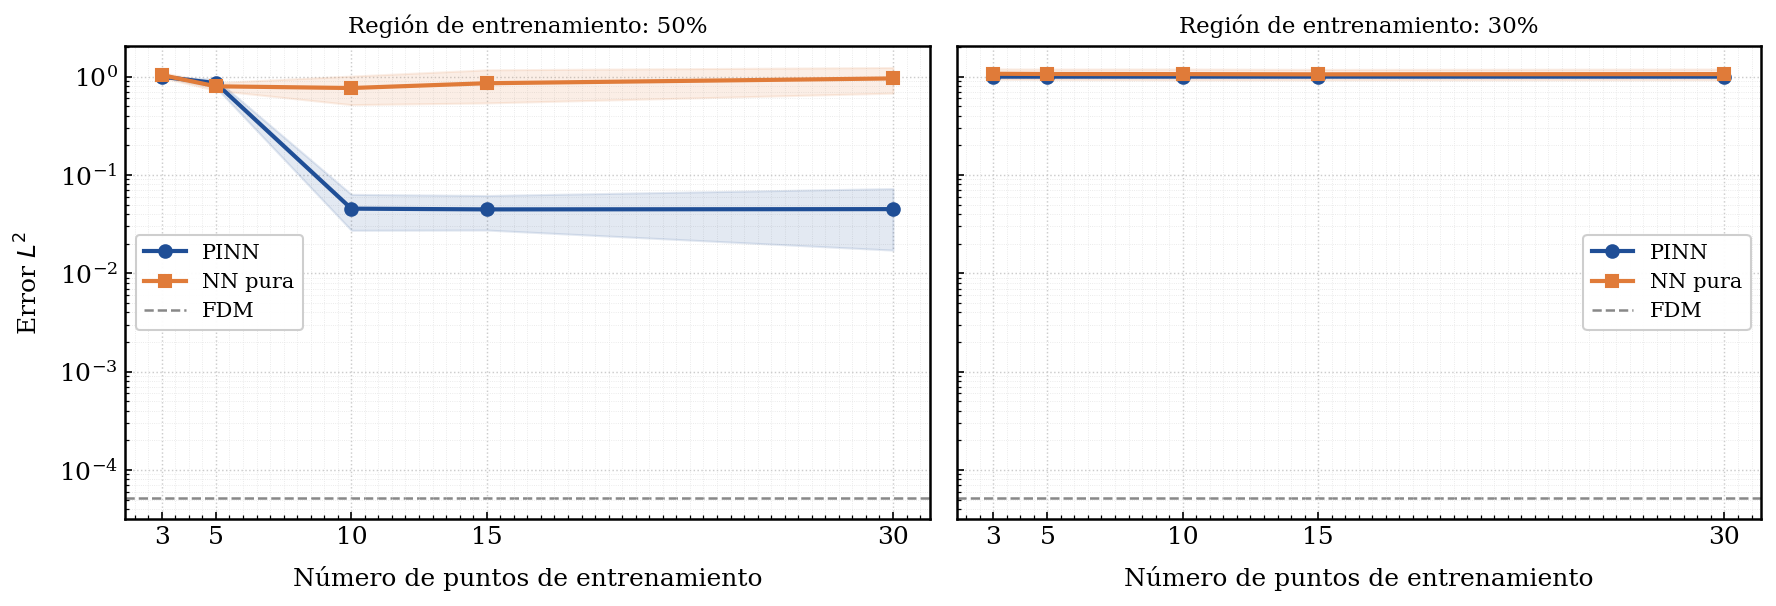

Región 50%:
  3 pts: PINN=9.9988e-01 ± 8.5210e-04 | NN=1.0369e+00 ± 6.0369e-02
  5 pts: PINN=8.5883e-01 ± 8.1723e-02 | NN=7.9740e-01 ± 7.2149e-02
  10 pts: PINN=4.5441e-02 ± 1.8066e-02 | NN=7.6607e-01 ± 2.4714e-01
  15 pts: PINN=4.4666e-02 ± 1.7125e-02 | NN=8.5690e-01 ± 3.1647e-01
  30 pts: PINN=4.4944e-02 ± 2.7730e-02 | NN=9.5915e-01 ± 2.7948e-01

Región 30%:
  3 pts: PINN=1.0001e+00 ± 2.3173e-04 | NN=1.0698e+00 ± 1.3005e-01
  5 pts: PINN=9.9961e-01 ± 1.2335e-03 | NN=1.0633e+00 ± 1.3170e-01
  10 pts: PINN=1.0003e+00 ± 2.3006e-03 | NN=1.0609e+00 ± 1.3535e-01
  15 pts: PINN=9.9973e-01 ± 1.0519e-03 | NN=1.0554e+00 ± 1.2954e-01
  30 pts: PINN=1.0000e+00 ± 1.9250e-04 | NN=1.0615e+00 ± 1.3391e-01

FDM: 5.2400e-05


In [23]:
mask_eje7_qho = (
    (df_qho["train_region"]       == 0.5) &
    (df_qho["estado_n"]           == BASE_QHO["estado_n"]) &
    (df_qho["num_domain_points"]  == BASE_QHO["num_domain_points"]) &
    (df_qho["sampler"]            == BASE_QHO["sampler"]) &
    (df_qho["use_dynamic_weights"]== BASE_QHO["use_dynamic_weights"]) &
    (df_qho["use_orthogonality"]  == BASE_QHO["use_orthogonality"]) &
    (df_qho["optimizer"]          == BASE_QHO["optimizer"]) &
    (df_qho["hidden_layers"]      == BASE_QHO["hidden_layers"]) &
    (df_qho["lr"]                 == BASE_QHO["lr"]) &
    (df_qho["use_data"]           == BASE_QHO["use_data"])
)

mask_eje9_qho = (
    (df_qho["train_region"]       == 0.3) &
    (df_qho["estado_n"]           == BASE_QHO["estado_n"]) &
    (df_qho["num_domain_points"]  == BASE_QHO["num_domain_points"]) &
    (df_qho["sampler"]            == BASE_QHO["sampler"]) &
    (df_qho["use_dynamic_weights"]== BASE_QHO["use_dynamic_weights"]) &
    (df_qho["use_orthogonality"]  == BASE_QHO["use_orthogonality"]) &
    (df_qho["optimizer"]          == BASE_QHO["optimizer"]) &
    (df_qho["hidden_layers"]      == BASE_QHO["hidden_layers"]) &
    (df_qho["lr"]                 == BASE_QHO["lr"]) &
    (df_qho["use_data"]           == BASE_QHO["use_data"])
)

df_eje7_qho = df_qho[mask_eje7_qho].groupby("num_train_points")[
    ["error_l2_pinn", "error_l2_nn"]
].agg(["mean", "std"]).reset_index()

df_eje9_qho = df_qho[mask_eje9_qho].groupby("num_train_points")[
    ["error_l2_pinn", "error_l2_nn"]
].agg(["mean", "std"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

for ax, df_e, region in zip(axes, [df_eje7_qho, df_eje9_qho], ["50%", "30%"]):
    x  = df_e["num_train_points"].values
    yp = df_e["error_l2_pinn"]["mean"].values
    sp = df_e["error_l2_pinn"]["std"].values
    yn = df_e["error_l2_nn"]["mean"].values
    sn = df_e["error_l2_nn"]["std"].values

    ax.plot(x, yp, "o-", color=C_PINN, linewidth=2, markersize=6,
            label="PINN", zorder=3)
    ax.fill_between(x, yp - sp, yp + sp, color=C_PINN, alpha=0.12, zorder=2)

    ax.plot(x, yn, "s-", color=C_NN, linewidth=2, markersize=6,
            label="NN pura", zorder=3)
    ax.fill_between(x, yn - sn, yn + sn, color=C_NN, alpha=0.12, zorder=2)

    ax.axhline(df_base_qho["error_l2_fdm"].mean(), color=C_FDM,
               linewidth=1.2, linestyle="--", label="FDM", zorder=1)

    ax.set_title(f"Región de entrenamiento: {region}", fontsize=11)
    ax.set_xlabel("Número de puntos de entrenamiento", labelpad=8)
    ax.set_yscale("log")
    ax.set_xticks([3, 5, 10, 15, 30])
    ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
    ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
    ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc")
    ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5")

axes[0].set_ylabel("Error $L^2$", labelpad=8)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje7_9_train_points.png", dpi=300, bbox_inches="tight")
plt.show()

print("Región 50%:")
for pts, grp in df_qho[mask_eje7_qho].groupby("num_train_points"):
    print(f"  {pts} pts: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print("\nRegión 30%:")
for pts, grp in df_qho[mask_eje9_qho].groupby("num_train_points"):
    print(f"  {pts} pts: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print(f"\nFDM: {df_base_qho['error_l2_fdm'].mean():.4e}")

## Eje 10 — Estado cuántico

Se estudia cómo varía el rendimiento de los tres métodos al cambiar el número
cuántico n (0, 1, 2, 3). A mayor n la función de onda presenta más oscilaciones,
lo que supone un reto creciente. Además del error L2 se analiza el error relativo
en el autovalor aprendido por la PINN frente al calculado por FDM.

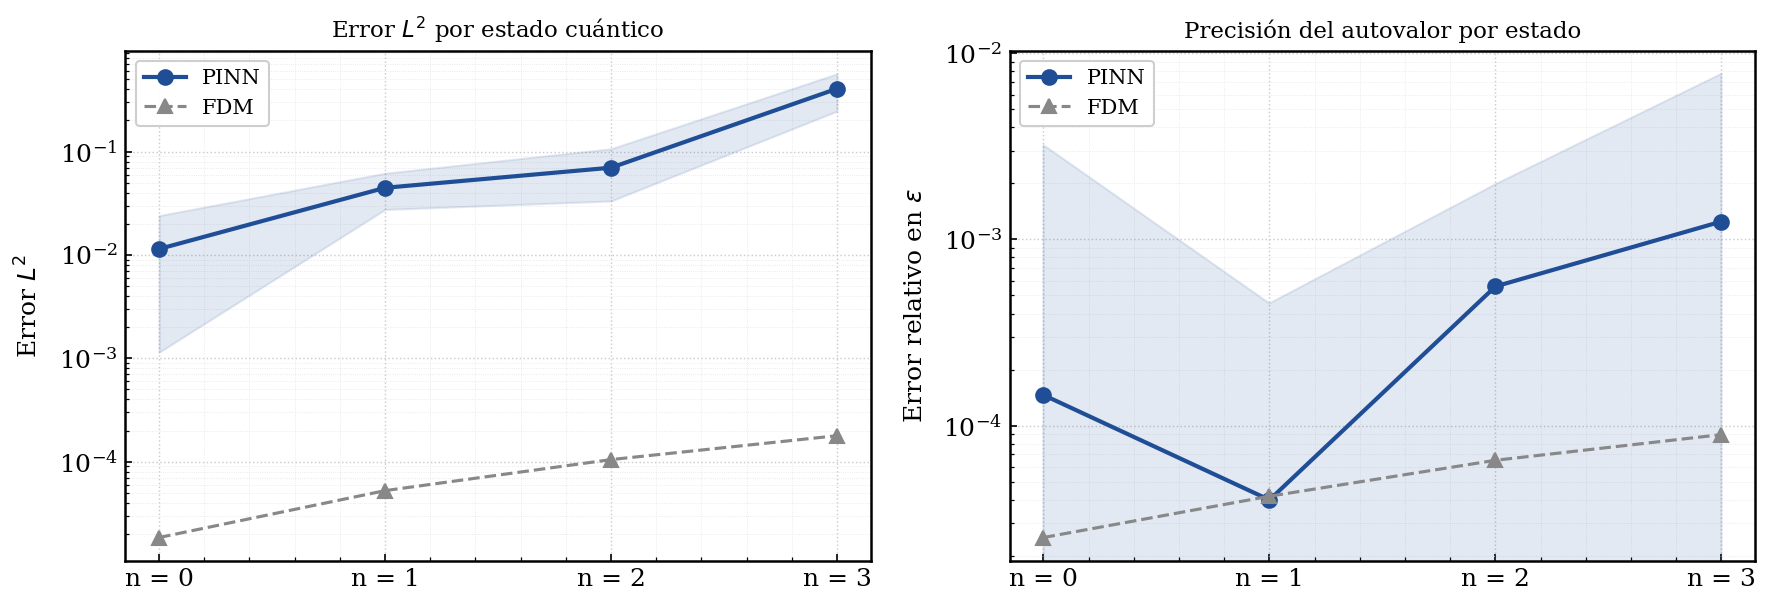

n           PINN L2       FDM L2   ε exacto     ε PINN      ε FDM
0        1.1425e-02   1.8436e-05     0.5000     0.5001     0.5000
1        4.4666e-02   5.2400e-05     1.5000     1.5001     1.4999
2        6.9895e-02   1.0467e-04     2.5000     2.5014     2.4998
3        4.0646e-01   1.7826e-04     3.5000     3.5044     3.4997


In [31]:
mask_eje10_qho = (
    df_qho["estado_n"].isin([0, 1, 2, 3]) &
    (df_qho["num_domain_points"]  == BASE_QHO["num_domain_points"]) &
    (df_qho["num_train_points"]   == BASE_QHO["num_train_points"]) &
    (df_qho["train_region"]       == BASE_QHO["train_region"]) &
    (df_qho["sampler"]            == BASE_QHO["sampler"]) &
    (df_qho["use_dynamic_weights"]== BASE_QHO["use_dynamic_weights"]) &
    (df_qho["use_orthogonality"]  == BASE_QHO["use_orthogonality"]) &
    (df_qho["optimizer"]          == BASE_QHO["optimizer"]) &
    (df_qho["hidden_layers"]      == BASE_QHO["hidden_layers"]) &
    (df_qho["lr"]                 == BASE_QHO["lr"]) &
    (df_qho["use_data"]           == BASE_QHO["use_data"])
)

df_eje10_qho = df_qho[mask_eje10_qho].groupby("estado_n").agg(
    pinn_mean    =("error_l2_pinn",   "mean"),
    pinn_std     =("error_l2_pinn",   "std"),
    nn_mean      =("error_l2_nn",     "mean"),
    nn_std       =("error_l2_nn",     "std"),
    fdm_mean     =("error_l2_fdm",    "mean"),
    fdm_std      =("error_l2_fdm",    "std"),
    eps_exact    =("epsilon_exacto",  "first"),
    eps_pinn_mean=("epsilon_learned", "mean"),
    eps_pinn_std =("epsilon_learned", "std"),
    eps_fdm_mean =("epsilon_fdm",     "mean"),
).reset_index()

x = df_eje10_qho["estado_n"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Panel izquierdo: error L2 por estado ──────────────────────────────────
ax = axes[0]
ax.plot(x, df_eje10_qho["pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=7, label="PINN", zorder=3)
ax.fill_between(x,
    np.maximum(df_eje10_qho["pinn_mean"] - df_eje10_qho["pinn_std"],
               df_eje10_qho["pinn_mean"] * 0.1),
    df_eje10_qho["pinn_mean"] + df_eje10_qho["pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, df_eje10_qho["fdm_mean"], "^--", color=C_FDM, linewidth=1.5,
        markersize=7, label="FDM", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([f"n = {n}" for n in x])
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$ por estado cuántico", fontsize=11)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: error relativo en autovalor ────────────────────────────
ax = axes[1]
eps_err_pinn     = np.abs(df_eje10_qho["eps_pinn_mean"] - df_eje10_qho["eps_exact"]) / df_eje10_qho["eps_exact"]
eps_err_pinn_std = df_eje10_qho["eps_pinn_std"] / df_eje10_qho["eps_exact"]
eps_err_fdm      = np.abs(df_eje10_qho["eps_fdm_mean"]  - df_eje10_qho["eps_exact"]) / df_eje10_qho["eps_exact"]

ax.plot(x, eps_err_pinn, "o-", color=C_PINN, linewidth=2,
        markersize=7, label="PINN", zorder=3)
ax.fill_between(x, eps_err_pinn - eps_err_pinn_std,
                   eps_err_pinn + eps_err_pinn_std,
                color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, eps_err_fdm, "^--", color=C_FDM, linewidth=1.5,
        markersize=7, label="FDM", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([f"n = {n}" for n in x])
ax.set_ylabel("Error relativo en $\\varepsilon$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Precisión del autovalor por estado", fontsize=11)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje10_estado_cuantico_qho.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Tabla numérica (sin NN) ───────────────────────────────────────────────
print(f"{'n':<6} {'PINN L2':>12} {'FDM L2':>12} "
      f"{'ε exacto':>10} {'ε PINN':>10} {'ε FDM':>10}")
for _, row in df_eje10_qho.iterrows():
    print(f"{int(row['estado_n']):<6} {row['pinn_mean']:>12.4e} "
          f"{row['fdm_mean']:>12.4e} {row['eps_exact']:>10.4f} "
          f"{row['eps_pinn_mean']:>10.4f} {row['eps_fdm_mean']:>10.4f}")

## Eje 11 — Sin datos supervisados

Se estudia el caso en que la PINN opera únicamente con la pérdida física, sin
ningún punto de entrenamiento supervisado (use_data=False). Este modo es
exclusivo de la PINN — la NN pura no puede entrenarse sin datos y se omite.
Se compara frente al BASE (con datos) y frente a FDM.

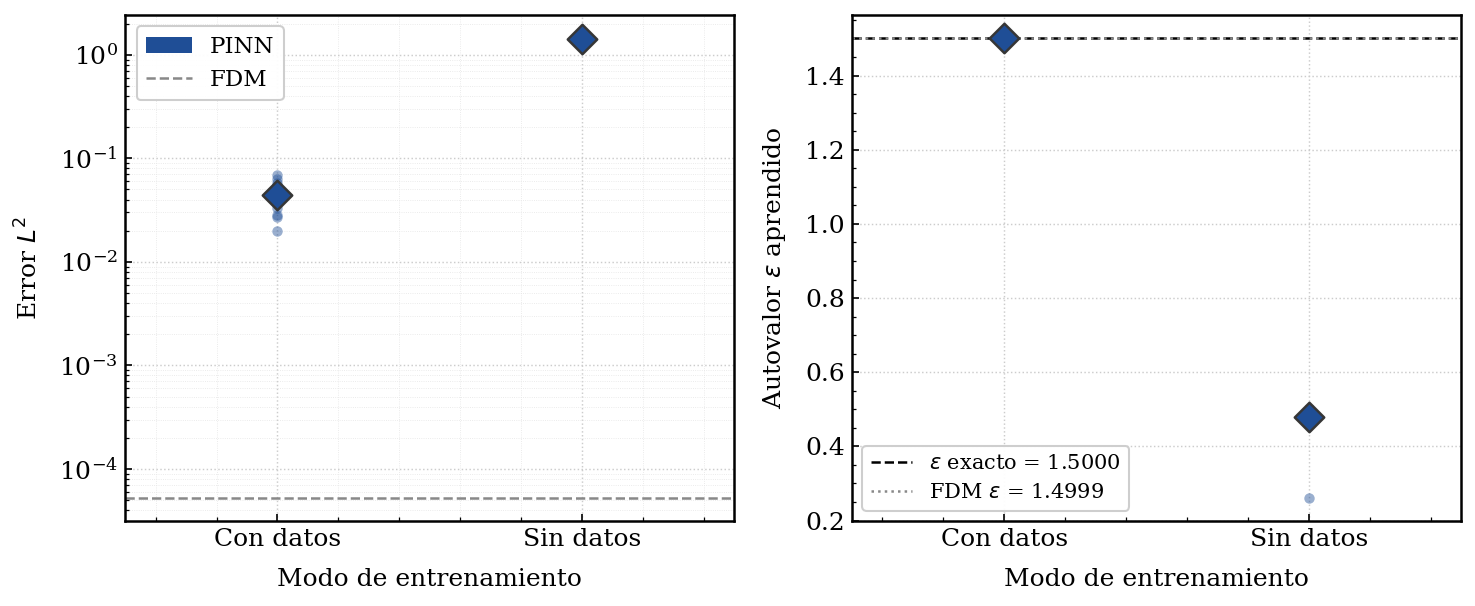

Con datos:  PINN=4.4666e-02 ± 1.7125e-02 | ε=1.500060 ± 0.000620
Sin datos:  PINN=1.4175e+00 ± 1.1374e-02 | ε=0.478394 ± 0.072215
ε exacto:   1.500000
FDM:        error=5.2400e-05 | ε=1.499937


In [25]:
mask_eje11_qho = (
    (df_qho["use_data"]           == False) &
    (df_qho["estado_n"]           == BASE_QHO["estado_n"]) &
    (df_qho["num_domain_points"]  == BASE_QHO["num_domain_points"]) &
    (df_qho["num_train_points"]   == BASE_QHO["num_train_points"]) &
    (df_qho["train_region"]       == BASE_QHO["train_region"]) &
    (df_qho["sampler"]            == BASE_QHO["sampler"]) &
    (df_qho["use_dynamic_weights"]== BASE_QHO["use_dynamic_weights"]) &
    (df_qho["use_orthogonality"]  == BASE_QHO["use_orthogonality"]) &
    (df_qho["optimizer"]          == BASE_QHO["optimizer"]) &
    (df_qho["hidden_layers"]      == BASE_QHO["hidden_layers"]) &
    (df_qho["lr"]                 == BASE_QHO["lr"])
)

grp11_qho = df_qho[mask_eje11_qho]

df_eje11_qho = pd.concat([
    df_base_qho[["error_l2_pinn", "epsilon_learned"]].assign(modo="Con datos"),
    grp11_qho[["error_l2_pinn", "epsilon_learned"]].assign(modo="Sin datos"),
])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.stripplot(
    data=df_eje11_qho, x="modo", y="error_l2_pinn",
    color=C_PINN, order=["Con datos", "Sin datos"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_11 = df_eje11_qho.groupby("modo")["error_l2_pinn"].mean().reset_index()
sns.stripplot(
    data=means_11, x="modo", y="error_l2_pinn",
    color=C_PINN, order=["Con datos", "Sin datos"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)

ax.axhline(
    df_base_qho["error_l2_fdm"].mean(),
    color=C_FDM, linewidth=1.2, linestyle="--", label="FDM", zorder=2
)
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=11)
ax.set_xlabel("Modo de entrenamiento", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: autovalor aprendido ───────────────────────────────────
ax = axes[1]
eps_exacto = df_base_qho["epsilon_exacto"].iloc[0]

sns.stripplot(
    data=df_eje11_qho, x="modo", y="epsilon_learned",
    color=C_PINN, order=["Con datos", "Sin datos"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_eps = df_eje11_qho.groupby("modo")["epsilon_learned"].mean().reset_index()
sns.stripplot(
    data=means_eps, x="modo", y="epsilon_learned",
    color=C_PINN, order=["Con datos", "Sin datos"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(eps_exacto, color="black", linewidth=1.2, linestyle="--",
           label=f"$\\varepsilon$ exacto = {eps_exacto:.4f}")
ax.axhline(
    df_base_qho["epsilon_fdm"].mean(), color=C_FDM, linewidth=1.2, linestyle=":",
    label=f"FDM $\\varepsilon$ = {df_base_qho['epsilon_fdm'].mean():.4f}"
)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Modo de entrenamiento", labelpad=8)
ax.set_ylabel("Autovalor $\\varepsilon$ aprendido", labelpad=8)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje11_sin_datos.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Con datos:  PINN={df_base_qho['error_l2_pinn'].mean():.4e} ± {df_base_qho['error_l2_pinn'].std():.4e} "
      f"| ε={df_base_qho['epsilon_learned'].mean():.6f} ± {df_base_qho['epsilon_learned'].std():.6f}")
print(f"Sin datos:  PINN={grp11_qho['error_l2_pinn'].mean():.4e} ± {grp11_qho['error_l2_pinn'].std():.4e} "
      f"| ε={grp11_qho['epsilon_learned'].mean():.6f} ± {grp11_qho['epsilon_learned'].std():.6f}")
print(f"ε exacto:   {eps_exacto:.6f}")
print(f"FDM:        error={df_base_qho['error_l2_fdm'].mean():.4e} "
      f"| ε={df_base_qho['epsilon_fdm'].mean():.6f}")

## Eje 12 — Ortogonalidad

Se estudia el efecto de añadir un término de ortogonalidad a la función de
pérdida. Este término penaliza la superposición con el estado anterior (n-1),
forzando a la red a aprender estados ortogonales. Es un eje exclusivo del QHO
y el pozo infinito. La NN pura no usa este término y se omite.

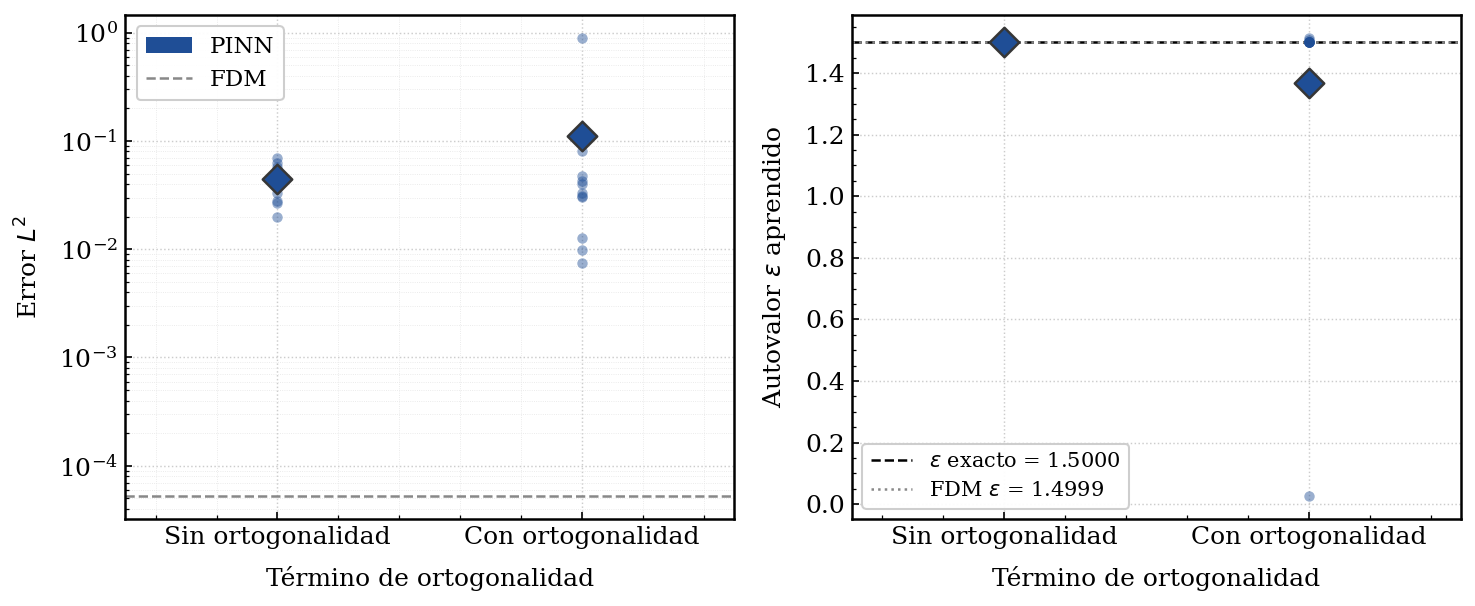

Sin ortogonalidad: PINN=4.4666e-02 ± 1.7125e-02 | ε=1.500060 ± 0.000620
Con ortogonalidad: PINN=1.1196e-01 ± 2.6078e-01 | ε=1.368167 ± 0.445002
ε exacto: 1.500000
FDM:      error=5.2400e-05 | ε=1.499937


In [26]:
mask_eje12_qho = (
    (df_qho["estado_n"]           == BASE_QHO["estado_n"]) &
    (df_qho["num_domain_points"]  == BASE_QHO["num_domain_points"]) &
    (df_qho["num_train_points"]   == BASE_QHO["num_train_points"]) &
    (df_qho["train_region"]       == BASE_QHO["train_region"]) &
    (df_qho["sampler"]            == BASE_QHO["sampler"]) &
    (df_qho["use_dynamic_weights"]== BASE_QHO["use_dynamic_weights"]) &
    (df_qho["optimizer"]          == BASE_QHO["optimizer"]) &
    (df_qho["hidden_layers"]      == BASE_QHO["hidden_layers"]) &
    (df_qho["lr"]                 == BASE_QHO["lr"]) &
    (df_qho["use_data"]           == BASE_QHO["use_data"])
)

df_eje12_qho = df_qho[mask_eje12_qho].copy()
df_eje12_qho["use_orthogonality"] = df_eje12_qho["use_orthogonality"].astype(str).map(
    {"False": "Sin ortogonalidad", "True": "Con ortogonalidad"}
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.stripplot(
    data=df_eje12_qho, x="use_orthogonality", y="error_l2_pinn",
    color=C_PINN,
    order=["Sin ortogonalidad", "Con ortogonalidad"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_12 = df_eje12_qho.groupby("use_orthogonality")["error_l2_pinn"].mean().reset_index()
sns.stripplot(
    data=means_12, x="use_orthogonality", y="error_l2_pinn",
    color=C_PINN,
    order=["Sin ortogonalidad", "Con ortogonalidad"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)

ax.axhline(
    df_base_qho["error_l2_fdm"].mean(),
    color=C_FDM, linewidth=1.2, linestyle="--", label="FDM", zorder=2
)
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=11)
ax.set_xlabel("Término de ortogonalidad", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: autovalor aprendido ────────────────────────────────────
ax = axes[1]
eps_exacto = df_base_qho["epsilon_exacto"].iloc[0]

sns.stripplot(
    data=df_eje12_qho, x="use_orthogonality", y="epsilon_learned",
    color=C_PINN,
    order=["Sin ortogonalidad", "Con ortogonalidad"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_eps12 = df_eje12_qho.groupby("use_orthogonality")["epsilon_learned"].mean().reset_index()
sns.stripplot(
    data=means_eps12, x="use_orthogonality", y="epsilon_learned",
    color=C_PINN,
    order=["Sin ortogonalidad", "Con ortogonalidad"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(eps_exacto, color="black", linewidth=1.2, linestyle="--",
           label=f"$\\varepsilon$ exacto = {eps_exacto:.4f}")
ax.axhline(
    df_base_qho["epsilon_fdm"].mean(), color=C_FDM, linewidth=1.2, linestyle=":",
    label=f"FDM $\\varepsilon$ = {df_base_qho['epsilon_fdm'].mean():.4f}"
)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Término de ortogonalidad", labelpad=8)
ax.set_ylabel("Autovalor $\\varepsilon$ aprendido", labelpad=8)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje12_orthogonality.png", dpi=300, bbox_inches="tight")
plt.show()

for ort, grp in df_qho[mask_eje12_qho].groupby("use_orthogonality"):
    label = "Con ortogonalidad" if ort else "Sin ortogonalidad"
    print(f"{label}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| ε={grp['epsilon_learned'].mean():.6f} ± {grp['epsilon_learned'].std():.6f}")
print(f"ε exacto: {eps_exacto:.6f}")
print(f"FDM:      error={df_base_qho['error_l2_fdm'].mean():.4e} "
      f"| ε={df_base_qho['epsilon_fdm'].mean():.6f}")

## Tabla resumen — todos los ejes

In [27]:
resumen_qho = []

# ── BASE ──────────────────────────────────────────────────────────────────
resumen_qho.append({
    "Eje":           "BASE",
    "Configuración": "—",
    "PINN media":    df_base_qho["error_l2_pinn"].mean(),
    "PINN std":      df_base_qho["error_l2_pinn"].std(),
    "NN media":      df_base_qho["error_l2_nn"].mean(),
    "NN std":        df_base_qho["error_l2_nn"].std(),
    "FDM media":     df_base_qho["error_l2_fdm"].mean(),
    "N":             len(df_base_qho),
})

# ── Ejes ──────────────────────────────────────────────────────────────────
ejes_qho = [
    ("Eje 1 · Puntos colocación",  "num_domain_points",   mask_eje1_qho),
    ("Eje 2 · Sampler",            "sampler",             mask_eje2_qho),
    ("Eje 3 · Optimizador",        "optimizer",           mask_eje3_qho),
    ("Eje 4 · Arquitectura",       "hidden_layers",       mask_eje4_qho),
    ("Eje 5 · Pesos dinámicos",    "use_dynamic_weights", mask_eje5_qho),
    ("Eje 6 · Learning rate",      "lr",                  mask_eje6_qho),
    ("Eje 7 · Puntos train 50%",   "num_train_points",    mask_eje7_qho),
    ("Eje 9 · Puntos train 30%",   "num_train_points",    mask_eje9_qho),
    ("Eje 10 · Estado cuántico",   "estado_n",            mask_eje10_qho),
]

for eje_label, col, mask in ejes_qho:
    for val, grp in df_qho[mask].groupby(col):
        resumen_qho.append({
            "Eje":           eje_label,
            "Configuración": str(val),
            "PINN media":    grp["error_l2_pinn"].mean(),
            "PINN std":      grp["error_l2_pinn"].std(),
            "NN media":      grp["error_l2_nn"].mean(),
            "NN std":        grp["error_l2_nn"].std(),
            "FDM media":     grp["error_l2_fdm"].mean(),
            "N":             len(grp),
        })

# ── Eje 11: sin datos ─────────────────────────────────────────────────────
resumen_qho.append({
    "Eje":           "Eje 11 · Sin datos",
    "Configuración": "use_data=False",
    "PINN media":    grp11_qho["error_l2_pinn"].mean(),
    "PINN std":      grp11_qho["error_l2_pinn"].std(),
    "NN media":      float("nan"),
    "NN std":        float("nan"),
    "FDM media":     grp11_qho["error_l2_fdm"].mean(),
    "N":             len(grp11_qho),
})

# ── Eje 12: ortogonalidad ─────────────────────────────────────────────────
for ort, grp in df_qho[mask_eje12_qho].groupby("use_orthogonality"):
    label = "Con ortogonalidad" if ort else "Sin ortogonalidad"
    resumen_qho.append({
        "Eje":           "Eje 12 · Ortogonalidad",
        "Configuración": label,
        "PINN media":    grp["error_l2_pinn"].mean(),
        "PINN std":      grp["error_l2_pinn"].std(),
        "NN media":      float("nan"),
        "NN std":        float("nan"),
        "FDM media":     grp["error_l2_fdm"].mean(),
        "N":             len(grp),
    })

# ── Formatear y mostrar ───────────────────────────────────────────────────
df_resumen_qho = pd.DataFrame(resumen_qho)

pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 130)

print(f"\n{'═'*115}")
print(f"{'EJE':<30} {'CONFIG':<22} {'PINN media':>12} {'PINN std':>12} "
      f"{'NN media':>12} {'NN std':>12} {'FDM media':>12} {'N':>4}")
print(f"{'─'*115}")

eje_actual = None
for _, row in df_resumen_qho.iterrows():
    if row["Eje"] != eje_actual:
        if eje_actual is not None:
            print(f"{'─'*115}")
        eje_actual = row["Eje"]
    nn_media = f"{row['NN media']:.3e}" if not pd.isna(row["NN media"]) else "N/A"
    nn_std   = f"{row['NN std']:.3e}"   if not pd.isna(row["NN std"])   else "N/A"
    print(f"{row['Eje']:<30} {row['Configuración']:<22} "
          f"{row['PINN media']:>12.3e} {row['PINN std']:>12.3e} "
          f"{nn_media:>12} {nn_std:>12} "
          f"{row['FDM media']:>12.3e} {int(row['N']):>4}")

print(f"{'═'*115}")


═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
EJE                            CONFIG                   PINN media     PINN std     NN media       NN std    FDM media    N
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BASE                           —                         4.467e-02    1.713e-02    8.569e-01    3.165e-01    5.240e-05   10
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Eje 1 · Puntos colocación      50                        5.829e-01    1.229e-01    8.509e-01    3.009e-01    5.240e-05   11
Eje 1 · Puntos colocación      100                       2.978e-01    1.644e-01    8.569e-01    3.165e-01    5.240e-05   10
Eje 1 · Puntos colocación      250                       4.427e-02    1.736e-02    8.569e-01    3.165e-01    5.240e-05   10
Eje 1 · Puntos colocación      